In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import seaborn as sns

In [11]:
# data
iris = load_iris()
X = iris.data
y_true = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# feature selection
X_petal = X[:, 2:4]  # petal_length, petal_width

# normalized
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_petal)

# linkage martix (distance and merge martrix)
linkage_matrix = linkage(X_scaled, method='ward')

# optimal k and 
K_range = range(2, 8)
silhouette_scores = []
ari_scores = []

for k in K_range:
    labels = fcluster(linkage_matrix, t=k, criterion='maxclust')
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    ari_scores.append(adjusted_rand_score(y_true, labels))
    print(f"K={k}: Silhouette={silhouette_scores[-1]:.4f}, ARI={ari_scores[-1]:.4f}")

# labels (k=3 has a good silhouethe score and ari)
hc = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)
labels_hc = hc.fit_predict(X_scaled)

# metrics
silhouette_hc = silhouette_score(X_scaled, labels_hc)
ari_hc = adjusted_rand_score(y_true, labels_hc)

print("="*50)
print(f"Number of clusters: {len(set(labels_hc))}")
print(f"Silhouette Score: {silhouette_hc:.4f}")
print(f"Adjusted Rand Index: {ari_hc:.4f}")
print(f"Cluster sizes: {np.bincount(labels_hc)}")

K=2: Silhouette=0.7434, ARI=0.5681
K=3: Silhouette=0.6099, ARI=0.6357
K=4: Silhouette=0.5791, ARI=0.6250
K=5: Silhouette=0.5619, ARI=0.6732
K=6: Silhouette=0.5724, ARI=0.6484
K=7: Silhouette=0.5488, ARI=0.5965
Number of clusters: 3
Silhouette Score: 0.6099
Adjusted Rand Index: 0.6357
Cluster sizes: [75 50 25]


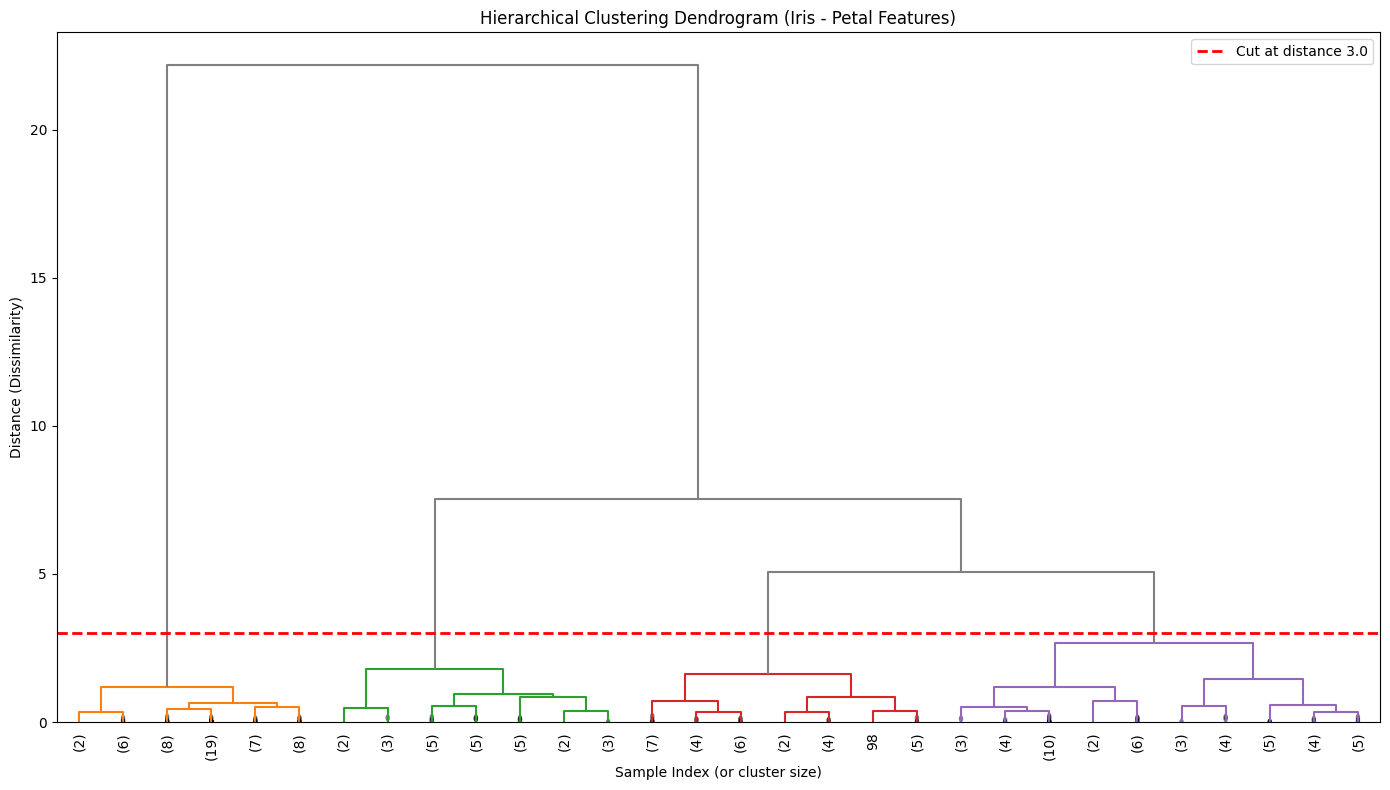

In [6]:
plt.figure(figsize=(14, 8))

# Plot dendrogram
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',  # only last p merged clusters
    p=30,                   # 30 clusters
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
    color_threshold=3.0,
    above_threshold_color='gray'
)

plt.axhline(y=3.0, color='red', linestyle='--', linewidth=2, label='Cut at distance 3.0')
plt.xlabel('Sample Index (or cluster size)')
plt.ylabel('Distance (Dissimilarity)')
plt.title('Hierarchical Clustering Dendrogram (Iris - Petal Features)')
plt.legend()
plt.tight_layout()
plt.show()

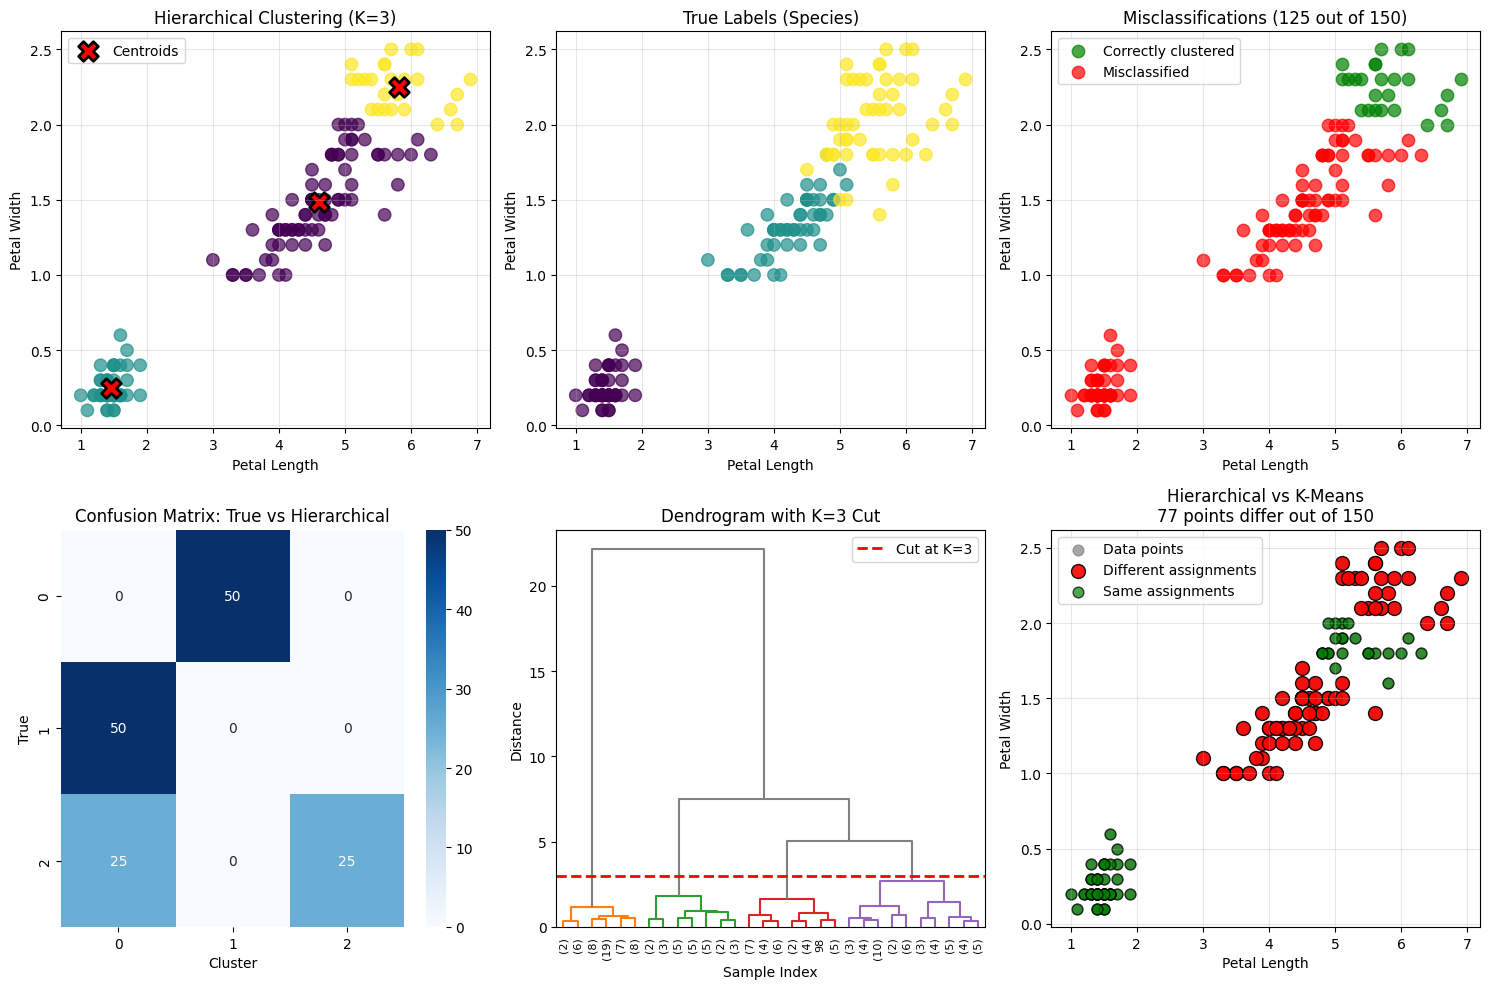

In [15]:
# Get cluster centers (mean of each cluster)
centers_hc = np.array([X_scaled[labels_hc == i].mean(axis=0) for i in range(3)])
centers_original = scaler.inverse_transform(centers_hc)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Hierarchical Clustering clusters
ax = axes[0, 0]
scatter = ax.scatter(X_petal[:, 0], X_petal[:, 1], c=labels_hc, cmap='viridis', s=80, alpha=0.7)
ax.scatter(centers_original[:, 0], centers_original[:, 1], 
           c='red', s=200, marker='X', edgecolors='black', linewidths=2, label='Centroids')
ax.set_xlabel('Petal Length')
ax.set_ylabel('Petal Width')
ax.set_title('Hierarchical Clustering (K=3)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: True labels
ax = axes[0, 1]
scatter = ax.scatter(X_petal[:, 0], X_petal[:, 1], c=y_true, cmap='viridis', s=80, alpha=0.7)
ax.set_xlabel('Petal Length')
ax.set_ylabel('Petal Width')
ax.set_title('True Labels (Species)')
ax.grid(True, alpha=0.3)

# Plot 3: Misclassifications
ax = axes[0, 2]
correct = (labels_hc == y_true)
ax.scatter(X_petal[correct, 0], X_petal[correct, 1], 
           c='green', s=80, alpha=0.7, label='Correctly clustered')
ax.scatter(X_petal[~correct, 0], X_petal[~correct, 1], 
           c='red', s=80, alpha=0.7, label='Misclassified')
ax.set_xlabel('Petal Length')
ax.set_ylabel('Petal Width')
ax.set_title(f'Misclassifications ({(~correct).sum()} out of {len(X)})')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Confusion Matrix
ax = axes[1, 0]
cm = pd.crosstab(y_true, labels_hc, rownames=['True'], colnames=['Cluster'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix: True vs Hierarchical')

# Plot 5: Dendrogram with colored clusters
ax = axes[1, 1]
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=8,
    ax=ax,
    color_threshold=3.0,
    above_threshold_color='gray'
)
ax.axhline(y=3.0, color='red', linestyle='--', linewidth=2, label='Cut at K=3')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Distance')
ax.set_title('Dendrogram with K=3 Cut')
ax.legend()

# Plot 6: Compare Hierarchical vs K-Means
ax = axes[1, 2]

# K-Means results for comparison
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

# Create comparison scatter
scatter = ax.scatter(X_petal[:, 0], X_petal[:, 1], 
                     c='gray', s=60, alpha=0.7, label='Data points')

# Highlight differences
diff = (labels_hc != labels_kmeans)
ax.scatter(X_petal[diff, 0], X_petal[diff, 1], 
           c='red', s=100, alpha=0.9, edgecolors='black', 
           label='Different assignments')
ax.scatter(X_petal[~diff, 0], X_petal[~diff, 1], 
           c='green', s=60, alpha=0.7, edgecolors='black', 
           label='Same assignments')

ax.set_xlabel('Petal Length')
ax.set_ylabel('Petal Width')
ax.set_title(f'Hierarchical vs K-Means\n{sum(diff)} points differ out of {len(X)}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()